In [ ]:
import numpy as np
import pandas as pd


In [ ]:
df = pd.read_csv("/content/placement.csv")

In [ ]:
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


**Steps to do this project**


1.   Preprocess + EDA + Feature seleection
2.   Extract input and output cols
3. Scale the values
4. Train test split- in this we train model in 90 insted of all data set 10 lest for testing model
5. Train the model
6. Evaluate the model/ model selection
7. Deployment



In [ ]:
df.info() # this is used to find there is any null value avalabe in any col
# find missing value.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [ ]:
df = df.iloc[:,1:] #this means original data set se sare rows chaheye aur col 1 se chaheye

In [ ]:
df.head() #this is used to display first n row of dataframe

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
# EDA
import matplotlib.pyplot as plt

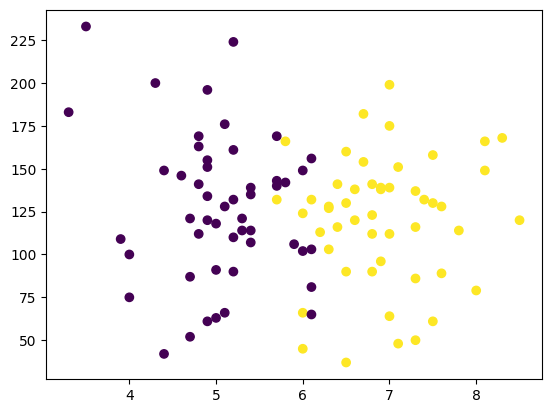

In [ ]:
#making scatter plot between cgpa and iq
plt.scatter(df['cgpa'],df['iq'],c=df['placement']) #to make color indication c=df['placement']

In [ ]:
# in this i use logestic regression
""" it cut data and find the line that seperate this data for such senerio this regression is good.
"""


' it cut data and find the line that seperate this data for such senerio this regression is good.\n'

In [ ]:
#set 2 extrance input and output col, cgpa iq is independent veriable and placement is dependent
x = df.iloc[:,0:2 ] # this means sare row chaheye aur col 0 se 1 tak
y = df.iloc[:,-1] # -1 indecate last col

In [ ]:
x #this is 2D tensor

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y.shape #this is 1D tensor

(100,)

In [ ]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.1) #test size tell us how many % of data go in training and test side
print("Done")

Done


In [ ]:
X_train

,cgpa,iq
58,8.0,79.0
98,6.3,103.0
72,7.3,116.0
53,8.3,168.0
92,5.2,110.0
...,...,...
13,6.4,116.0
70,6.3,127.0
16,5.2,224.0
40,4.9,134.0


In [ ]:
y_train

,placement
58,1
98,1
72,1
53,1
92,0
...,...
13,1
70,1
16,0
40,0


In [ ]:
X_test

,cgpa,iq
57,6.5,130.0
73,4.9,61.0
35,6.8,90.0
46,5.3,114.0
59,4.8,112.0
81,5.4,107.0
48,6.6,138.0
80,4.9,196.0
55,7.8,114.0
74,6.7,154.0


In [ ]:
y_test

,placement
57,1
73,0
35,1
46,0
59,0
81,0
48,1
80,0
55,1
74,1


In [ ]:
#scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train

array([[ 1.73930335, -1.11268954],
       [ 0.26580716, -0.51660586],
       [ 1.13256962, -0.1937272 ],
       [ 1.99933209,  1.09778744],
       [-0.68763156, -0.34274812],
       [-1.38104153, -2.03165188],
       [ 0.09245466, -1.0630159 ],
       [-1.03433654,  0.97360334],
       [ 0.09245466, -1.46040502],
       [ 0.87254088, -0.29307448],
       [-0.68763156,  0.20366192],
       [ 1.39259836, -0.86432134],
       [-0.7743078 ,  0.10431464],
       [ 1.30592211,  0.15398828],
       [ 0.61251214,  1.44550292],
       [ 0.17913091, -0.26823766],
       [-0.51427906,  0.37751966],
       [-1.38104153,  0.62588786],
       [-1.12101279, -1.78328368],
       [-2.16112775,  2.71218075],
       [-1.46771777,  1.89256569],
       [ 0.00577842, -1.95714142],
       [ 0.78586464,  0.37751966],
       [ 0.78586464, -0.6904636 ],
       [ 0.87254088,  0.37751966],
       [-0.08089783, -0.4420954 ],
       [ 1.13256962,  0.32784602],
       [-0.51427906,  0.27817238],
       [-0.9476603 ,

In [ ]:
X_test

array([[ 0.43915965,  0.15398828],
       [-0.9476603 , -1.5597523 ],
       [ 0.69918839, -0.83948452],
       [-0.60095531, -0.24340084],
       [-1.03433654, -0.29307448],
       [-0.51427906, -0.41725858],
       [ 0.5258359 ,  0.35268284],
       [-0.9476603 ,  1.79321841],
       [ 1.56595085, -0.24340084],
       [ 0.61251214,  0.75007196]])

In [ ]:
# Train the model
from sklearn.linear_model import LogisticRegression

In [ ]:
clf = LogisticRegression() # make object clf that have power to use function that is in LogisticRegression function class


In [ ]:
clf.fit(X_train, y_train) # .fit is used to train the data inside the () we provie train data of x and y

LogisticRegression()

In [ ]:
#evaluate the model- by finding acuracy on test data
y_pred = clf.predict(X_test)

In [ ]:
y_test #this tell us the actual result of placement huaa ya nahi

,placement
57,1
73,0
35,1
46,0
59,0
81,0
48,1
80,0
55,1
74,1


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred) #this give 1.0 that means your model achieved 100% accuracy on the test dataset.

1.0

In [ ]:
# how to plot decision boundry
from mlxtend.plotting import plot_decision_regions

<Axes: >

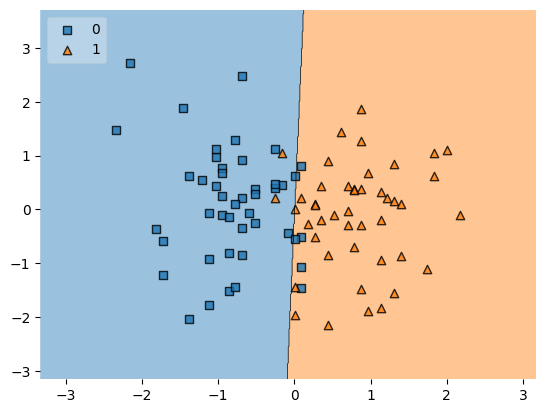

In [ ]:
# Plotting decision regions
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)
#x_train is already in numpy array but y_train is not so make it numpy array


In [ ]:
import pickle # this make object convert it into file and this file is used in any other invironment

In [ ]:
pickle.dump(clf,open('model.pkl','wb')) # wb represent that ke hum es file ko wright binary mode me open kar rahe hai